# Energy Consumption EDA, Feature Engineering & Baseline Model
**Dataset:** GRID-India Weekly PSP Reports | Apr 2023 – Mar 2026
**Target:** `Energy_Consumption_MU` (daily state-level energy consumption in Million Units)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = sns.color_palette('tab10')

# ── Load data ─────────────────────────────────────────────────────────────
# UPDATE THIS PATH to your local dataset folder
DATA_PATH = r'C:\Users\Savio Winson\Desktop\Energy Consumption\dataset\master_state_daily.csv'

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df[df['State'] != 'ALL_INDIA'].copy()   # drop national total rows
df = df.sort_values(['State', 'Date']).reset_index(drop=True)

print(f'Rows: {len(df):,}  |  Date range: {df.Date.min().date()} → {df.Date.max().date()}')
print(f'States: {df.State.nunique()}  |  Columns: {list(df.columns)}')
df.head(3)

Rows: 38,150  |  Date range: 2023-04-17 → 2026-03-08
States: 39  |  Columns: ['Date', 'State', 'Region', 'Energy_Consumption_MU', 'MaxDemand_MW', 'PeakShortage_MW', 'Reg_EveningDemand_MW', 'Reg_EveningShortage_MW', 'Reg_EnergyMet_MU', 'Reg_HydroGen_MU', 'Grid_AvgFreq_Hz', 'Grid_FreqVariationIndex', 'Grid_NormalBand_pct', 'Bhutan_Exchange_MU', 'Bhutan_DayPeak_MW', 'Nepal_Exchange_MU', 'Nepal_DayPeak_MW', 'Bangladesh_Exchange_MU', 'Bangladesh_DayPeak_MW']


,Date,State,Region,Energy_Consumption_MU,MaxDemand_MW,PeakShortage_MW,Reg_EveningDemand_MW,Reg_EveningShortage_MW,Reg_EnergyMet_MU,Reg_HydroGen_MU,Grid_AvgFreq_Hz,Grid_FreqVariationIndex,Grid_NormalBand_pct,Bhutan_Exchange_MU,Bhutan_DayPeak_MW,Nepal_Exchange_MU,Nepal_DayPeak_MW,Bangladesh_Exchange_MU,Bangladesh_DayPeak_MW
0,2023-04-17,AMNSIL,WR,17.7,819.0,0.0,62760.0,177.0,1509.0,44.0,50.0,0.079,59.19,2.2,90.0,-753.0,-555.0,-1102.0,-1039.0
1,2023-04-18,AMNSIL,WR,17.4,820.0,0.0,63593.0,375.0,1539.0,46.0,50.0,0.041,73.88,0.9,38.0,-712.0,-607.0,-1104.0,-1053.0
2,2023-04-19,AMNSIL,WR,18.1,868.0,0.0,62902.0,NaN,1537.0,41.0,50.0,0.053,67.25,4.1,170.0,-607.0,-471.0,-1101.0,-1062.0


## 1. Dataset Overview

In [3]:
# Summary statistics for the target
print('=== Energy Consumption (MU) — All States ===')
print(df['Energy_Consumption_MU'].describe().round(2))

print('\n=== Missing values ===')
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
print(null_pct[null_pct > 0])

=== Energy Consumption (MU) — All States ===
count    38138.00
mean       119.28
std        145.93
min         -0.50
25%          6.10
50%         48.70
75%        202.30
max        689.00
Name: Energy_Consumption_MU, dtype: float64

=== Missing values ===
Reg_EveningShortage_MW    72.5
dtype: float64


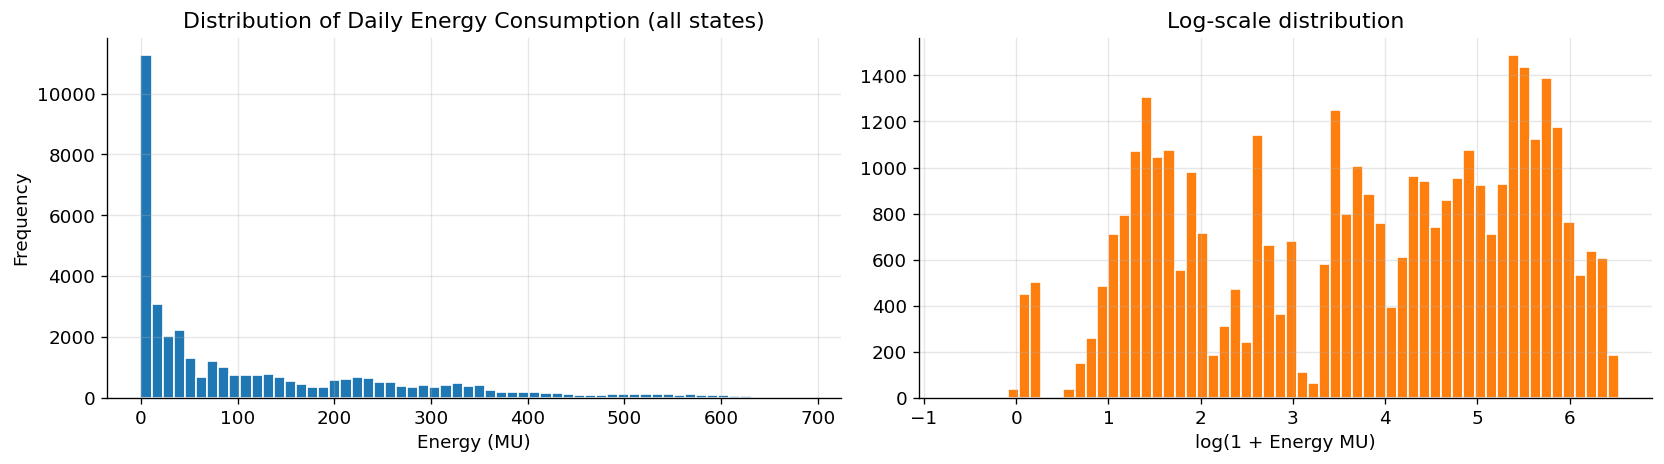

Right-skewed: a few large states (UP, Maharashtra, Gujarat, Tamil Nadu) dominate the distribution.


In [4]:
# Distribution of energy consumption
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Energy_Consumption_MU'].hist(bins=60, ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].set_title('Distribution of Daily Energy Consumption (all states)')
axes[0].set_xlabel('Energy (MU)')
axes[0].set_ylabel('Frequency')

# Log scale to see the spread better
np.log1p(df['Energy_Consumption_MU']).hist(bins=60, ax=axes[1], color=PALETTE[1], edgecolor='white')
axes[1].set_title('Log-scale distribution')
axes[1].set_xlabel('log(1 + Energy MU)')

plt.tight_layout()
plt.show()
print('Right-skewed: a few large states (UP, Maharashtra, Gujarat, Tamil Nadu) dominate the distribution.')

## 2. State-level Analysis

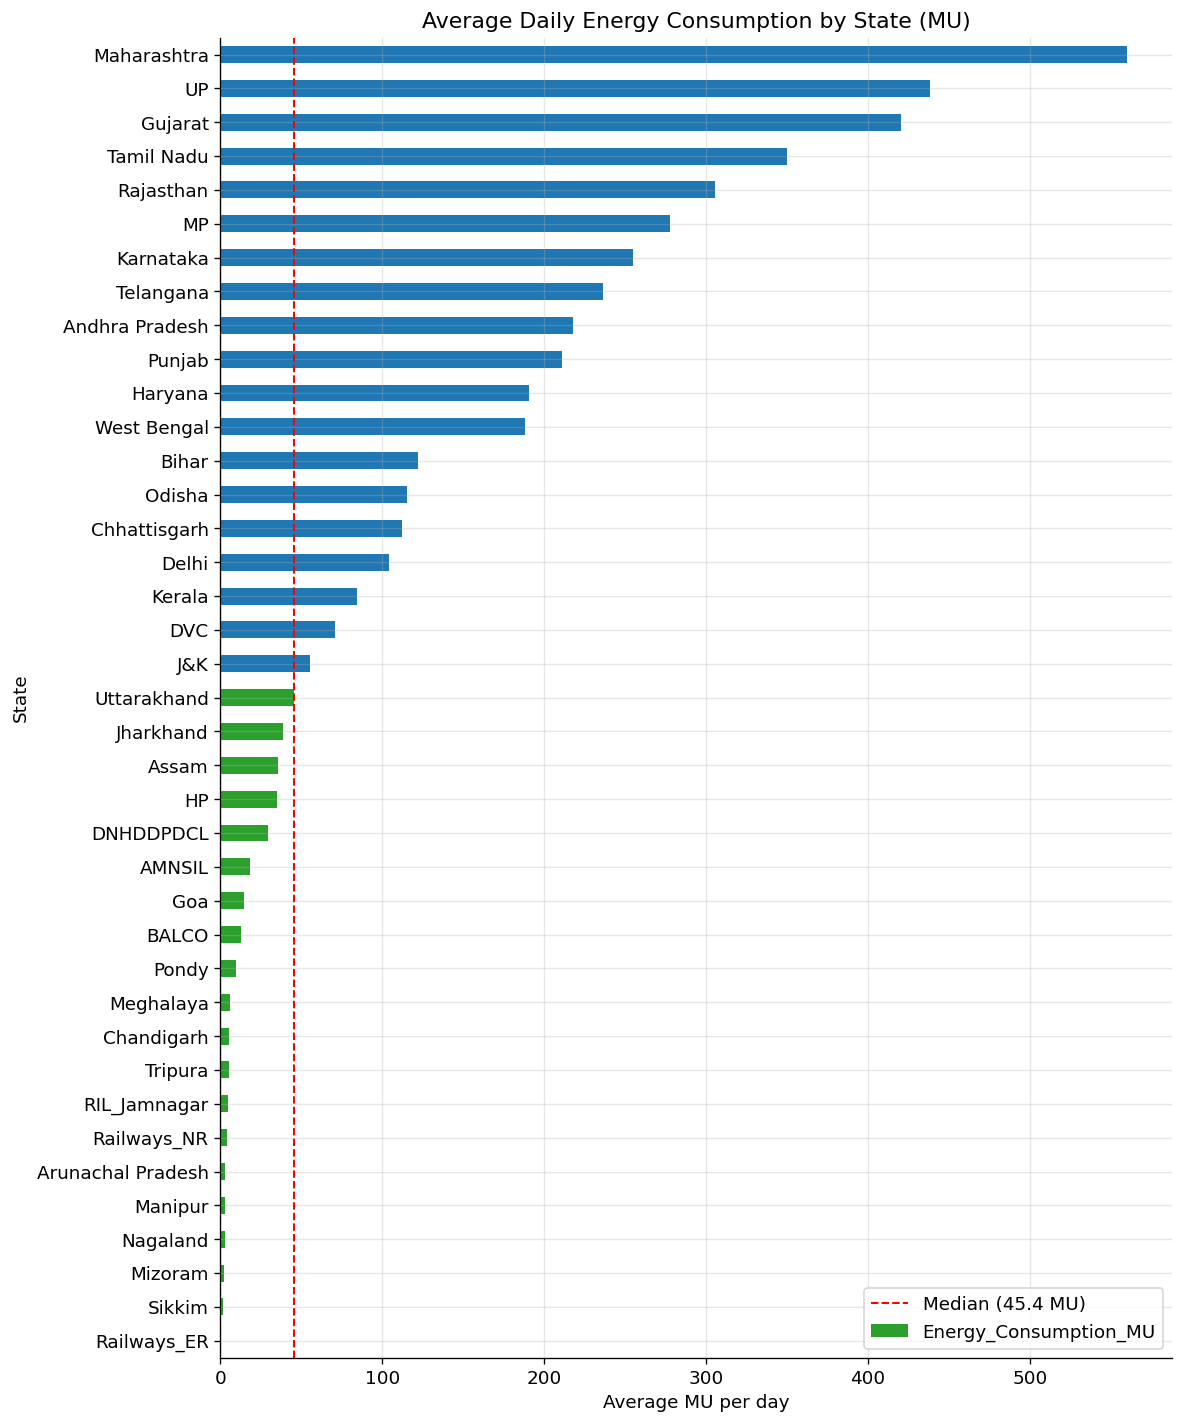

In [6]:
# Average daily consumption per state
state_avg = (df.groupby('State')['Energy_Consumption_MU']
              .mean()
              .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 12))
colors = [PALETTE[0] if v > state_avg.median() else PALETTE[2] for v in state_avg]
state_avg.plot(kind='barh', ax=ax, color=colors)
ax.axvline(state_avg.median(), color='red', linestyle='--', linewidth=1.2, label=f'Median ({state_avg.median():.1f} MU)')
ax.set_title('Average Daily Energy Consumption by State (MU)')
ax.set_xlabel('Average MU per day')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Top 10 states contribute what % of total consumption?
state_total = df.groupby('State')['Energy_Consumption_MU'].sum().sort_values(ascending=False)
grand_total = state_total.sum()
top10_share = state_total.head(10).sum() / grand_total * 100
print(f'Top 10 states share: {top10_share:.1f}% of all energy consumption')
print('\nTop 10 states:')
for st, val in state_total.head(10).items():
    print(f'  {st:<20} {val:>10,.0f} MU  ({val/grand_total*100:.1f}%)')

Top 10 states share: 71.3% of all energy consumption

Top 10 states:
  Maharashtra             556,684 MU  (12.2%)
  UP                      429,736 MU  (9.4%)
  Gujarat                 417,849 MU  (9.2%)
  Tamil Nadu              347,992 MU  (7.6%)
  Rajasthan               303,962 MU  (6.7%)
  MP                      272,050 MU  (6.0%)
  Karnataka               253,324 MU  (5.6%)
  Telangana               235,044 MU  (5.2%)
  Andhra Pradesh          216,541 MU  (4.8%)
  Punjab                  209,988 MU  (4.6%)


## 3. Temporal Patterns — Seasonality & Trends

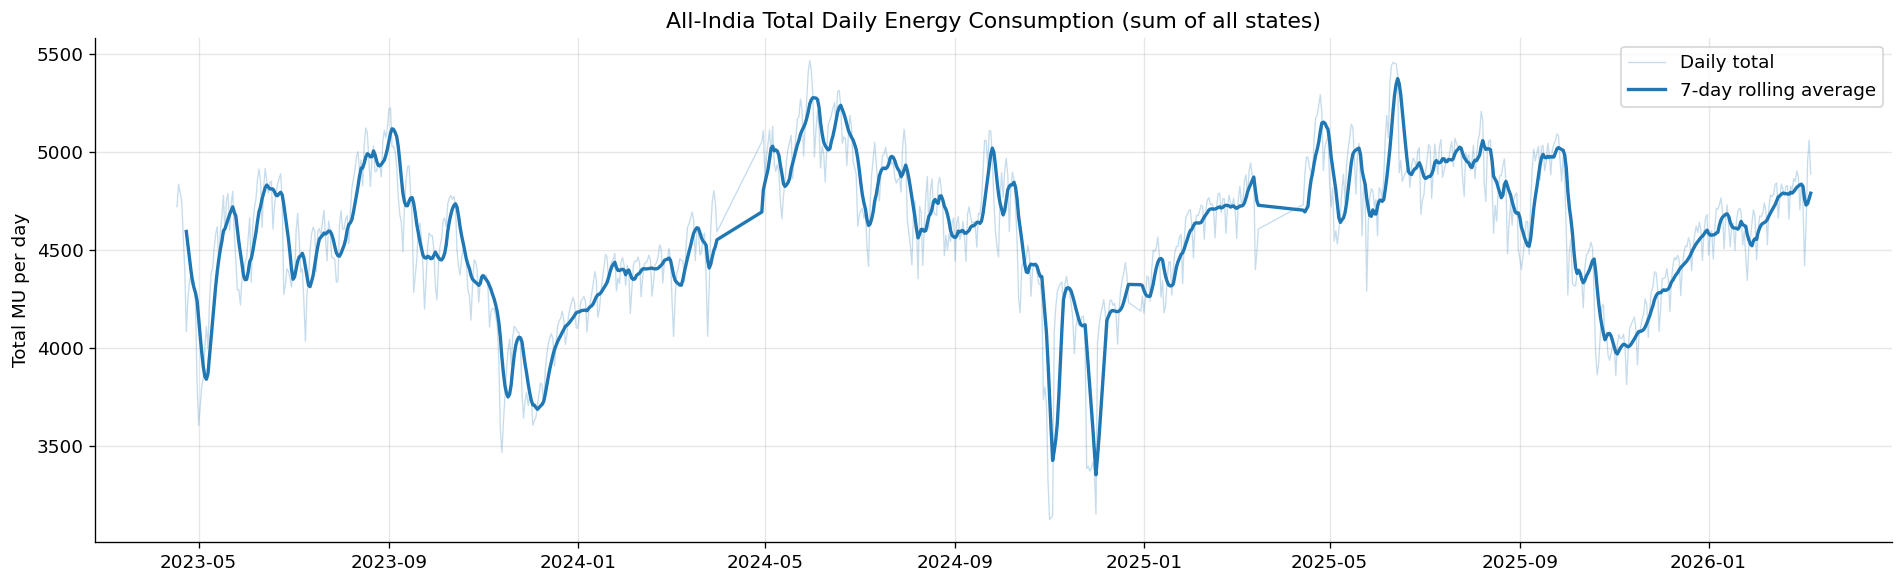

In [8]:
# All-India daily total (sum across states)
daily_total = df.groupby('Date')['Energy_Consumption_MU'].sum().reset_index()
daily_total['rolling_7'] = daily_total['Energy_Consumption_MU'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_total['Date'], daily_total['Energy_Consumption_MU'],
        alpha=0.25, color=PALETTE[0], linewidth=0.8, label='Daily total')
ax.plot(daily_total['Date'], daily_total['rolling_7'],
        color=PALETTE[0], linewidth=2, label='7-day rolling average')
ax.set_title('All-India Total Daily Energy Consumption (sum of all states)')
ax.set_ylabel('Total MU per day')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

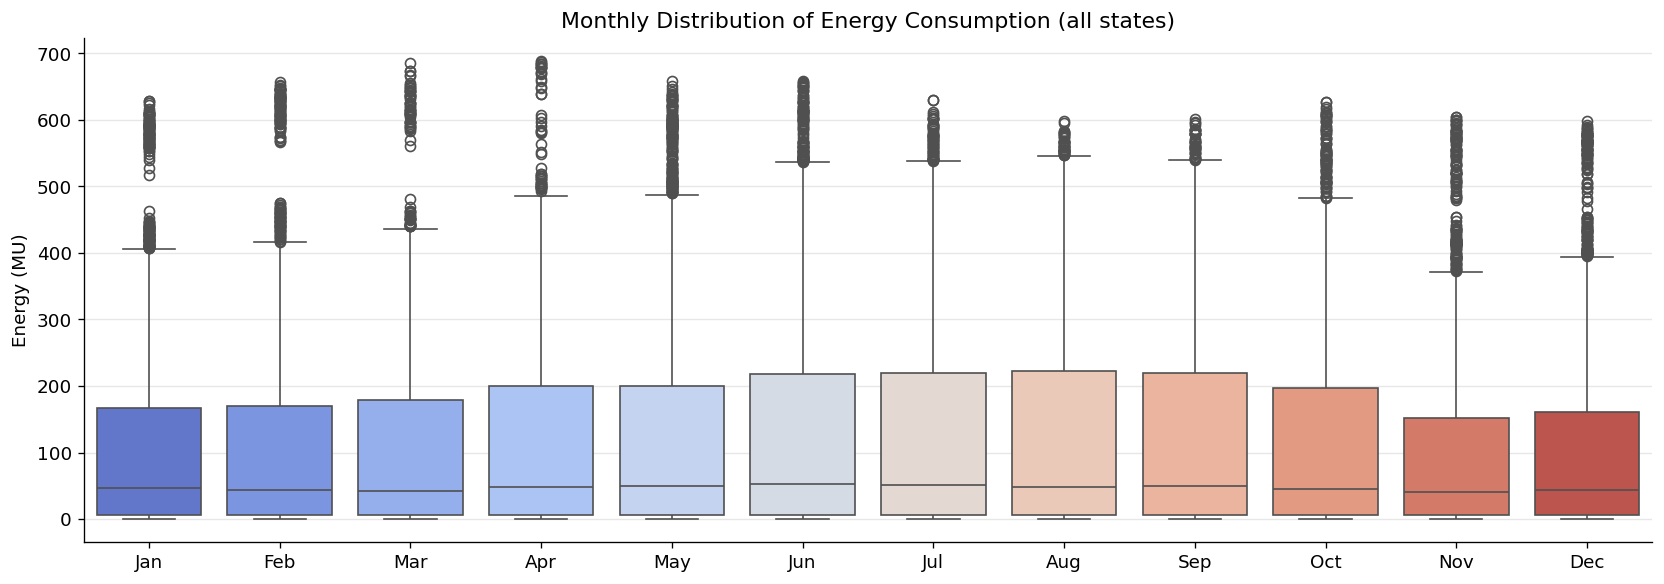

KEY INSIGHT: May-June peak (summer AC loads), dip in Sep-Oct (post-monsoon mild weather).


In [9]:
# Monthly seasonality — box plots
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df, x='MonthName', y='Energy_Consumption_MU',
            order=month_order, palette='coolwarm', ax=ax)
ax.set_title('Monthly Distribution of Energy Consumption (all states)')
ax.set_xlabel('')
ax.set_ylabel('Energy (MU)')
plt.tight_layout()
plt.show()
print('KEY INSIGHT: May-June peak (summer AC loads), dip in Sep-Oct (post-monsoon mild weather).')

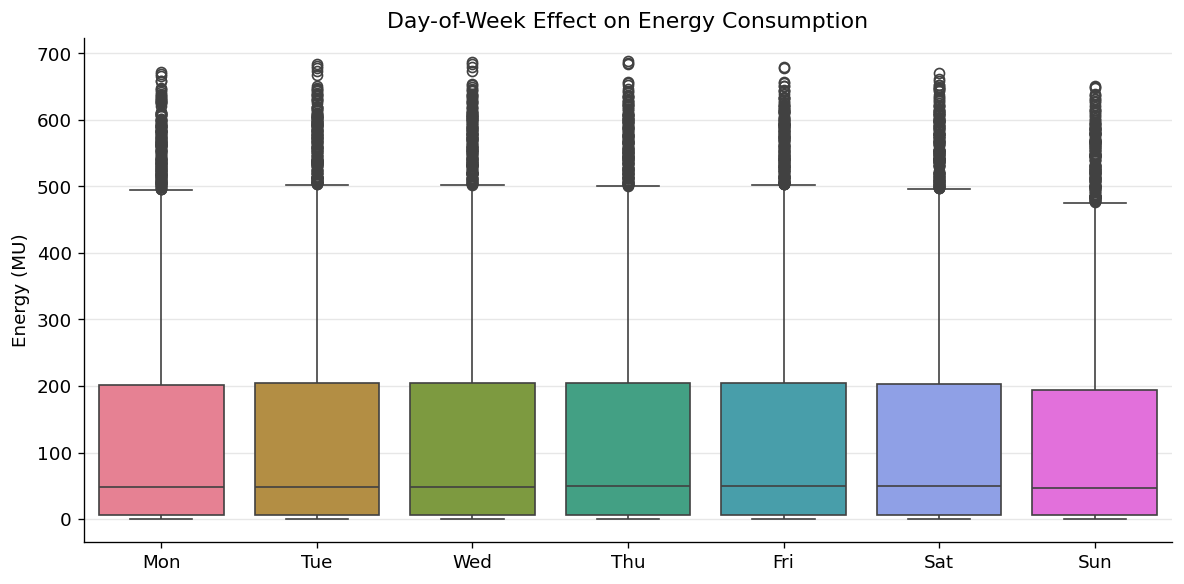

KEY INSIGHT: Sunday shows a clear dip — industrial load drops on weekends.


In [10]:
# Day-of-week effect — is there a weekend dip?
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Mon, 6=Sun
df['DayName']   = df['Date'].dt.strftime('%a')
dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='DayName', y='Energy_Consumption_MU',
            order=dow_order, palette='husl', ax=ax)
ax.set_title('Day-of-Week Effect on Energy Consumption')
ax.set_xlabel('')
ax.set_ylabel('Energy (MU)')
plt.tight_layout()
plt.show()
print('KEY INSIGHT: Sunday shows a clear dip — industrial load drops on weekends.')

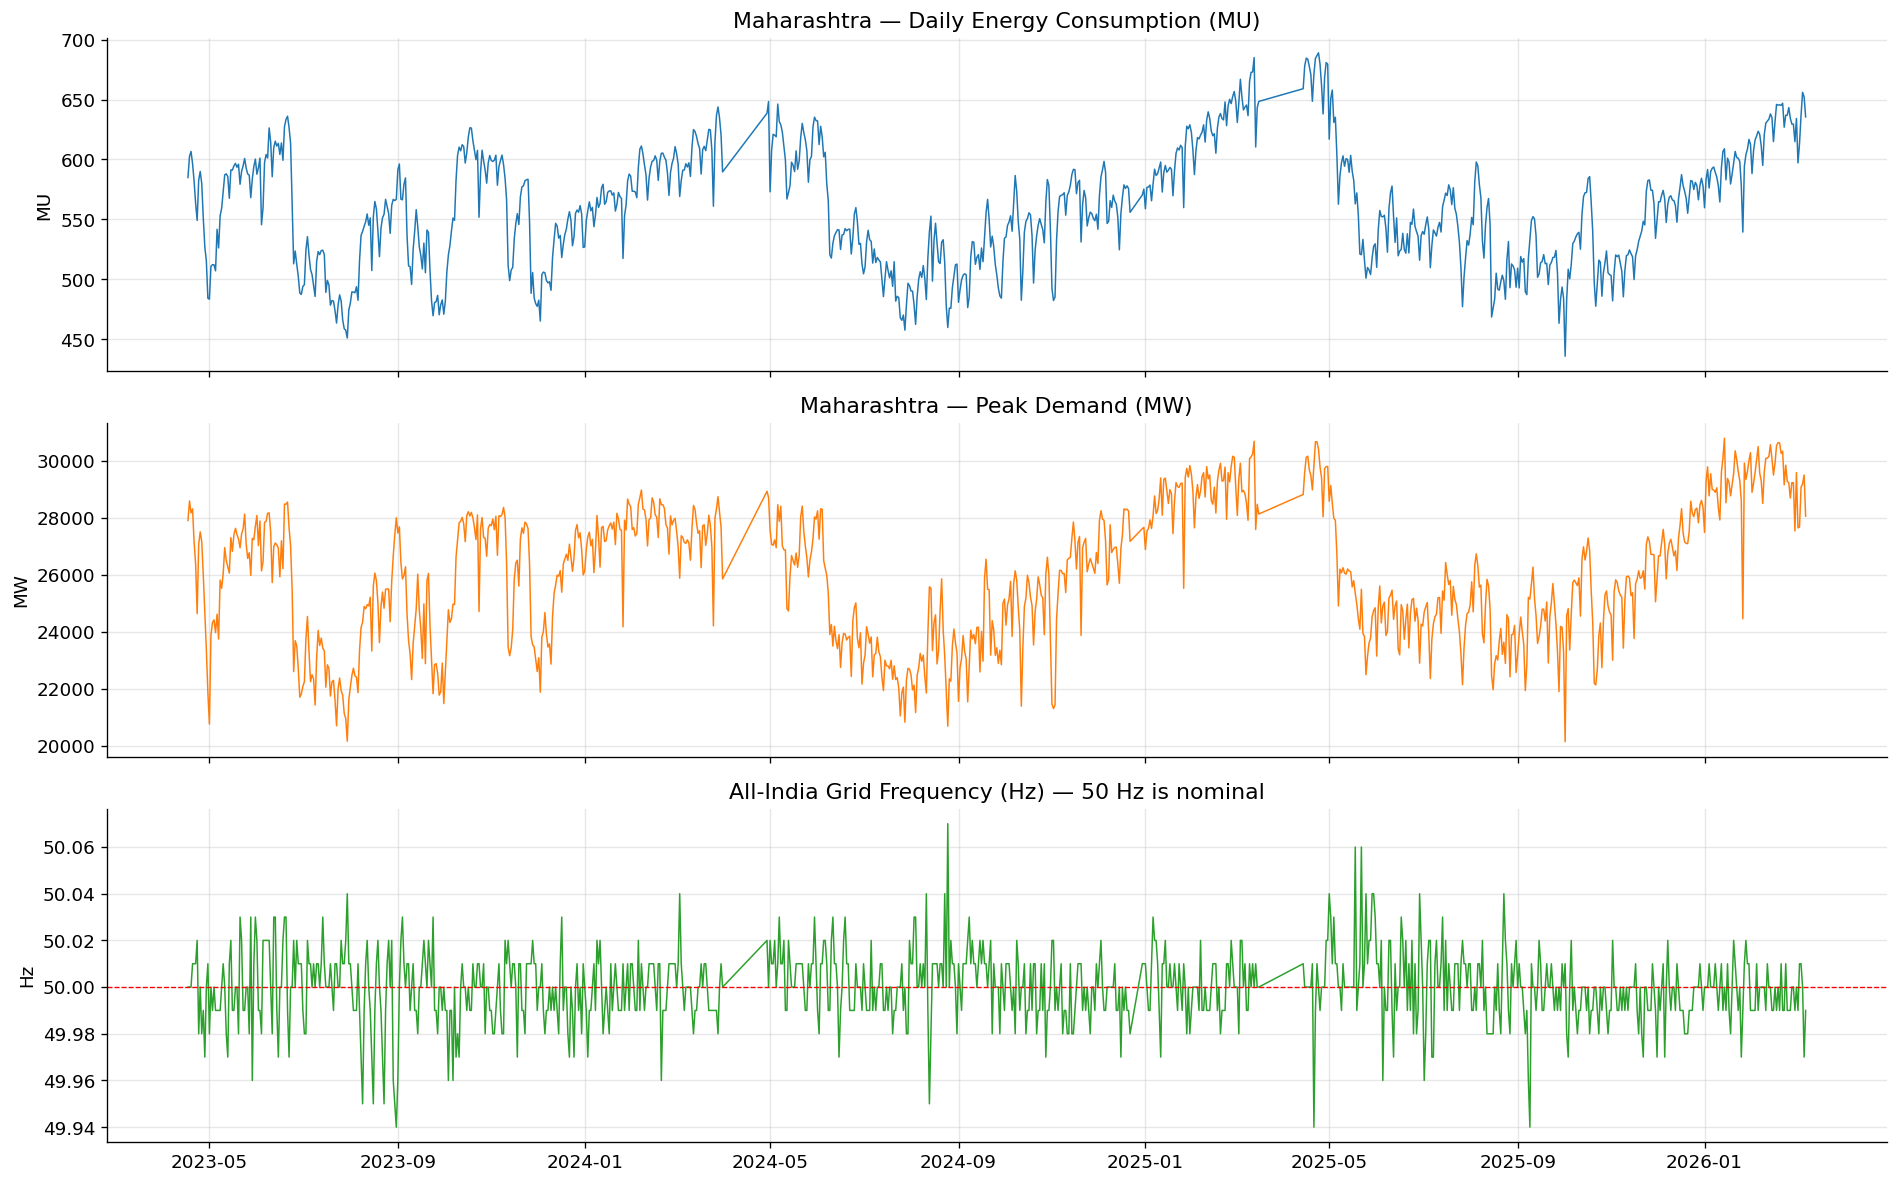

In [11]:
# Maharashtra time-series — single state deep dive
mh = df[df['State'] == 'Maharashtra'].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(mh['Date'], mh['Energy_Consumption_MU'], color=PALETTE[0], linewidth=0.9)
axes[0].set_title('Maharashtra — Daily Energy Consumption (MU)')
axes[0].set_ylabel('MU')

axes[1].plot(mh['Date'], mh['MaxDemand_MW'], color=PALETTE[1], linewidth=0.9)
axes[1].set_title('Maharashtra — Peak Demand (MW)')
axes[1].set_ylabel('MW')

axes[2].plot(mh['Date'], mh['Grid_AvgFreq_Hz'], color=PALETTE[2], linewidth=0.9)
axes[2].axhline(50.0, color='red', linestyle='--', linewidth=0.8)
axes[2].set_title('All-India Grid Frequency (Hz) — 50 Hz is nominal')
axes[2].set_ylabel('Hz')

plt.tight_layout()
plt.show()

## 4. Regional Analysis

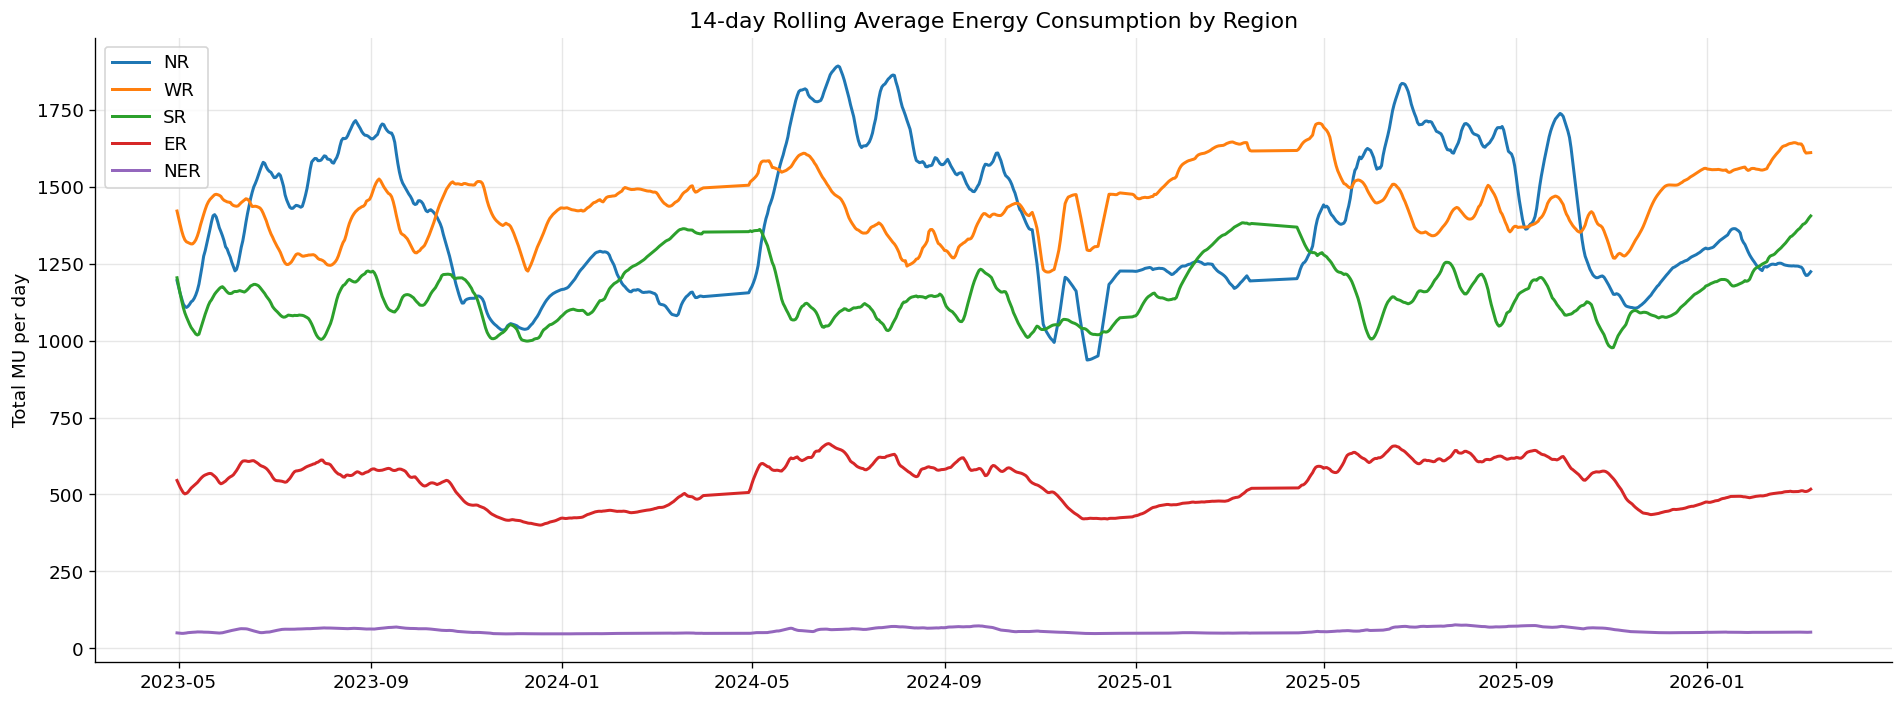

In [12]:
# Regional consumption over time
region_daily = (df[df['Region'].isin(['NR','WR','SR','ER','NER'])]
                .groupby(['Date','Region'])['Energy_Consumption_MU']
                .sum().reset_index())

fig, ax = plt.subplots(figsize=(16, 6))
for i, reg in enumerate(['NR','WR','SR','ER','NER']):
    subset = region_daily[region_daily['Region'] == reg]
    roll = subset.set_index('Date')['Energy_Consumption_MU'].rolling(14).mean()
    ax.plot(roll.index, roll.values, label=reg, color=PALETTE[i], linewidth=1.8)
ax.set_title('14-day Rolling Average Energy Consumption by Region')
ax.set_ylabel('Total MU per day')
ax.legend()
plt.tight_layout()
plt.show()

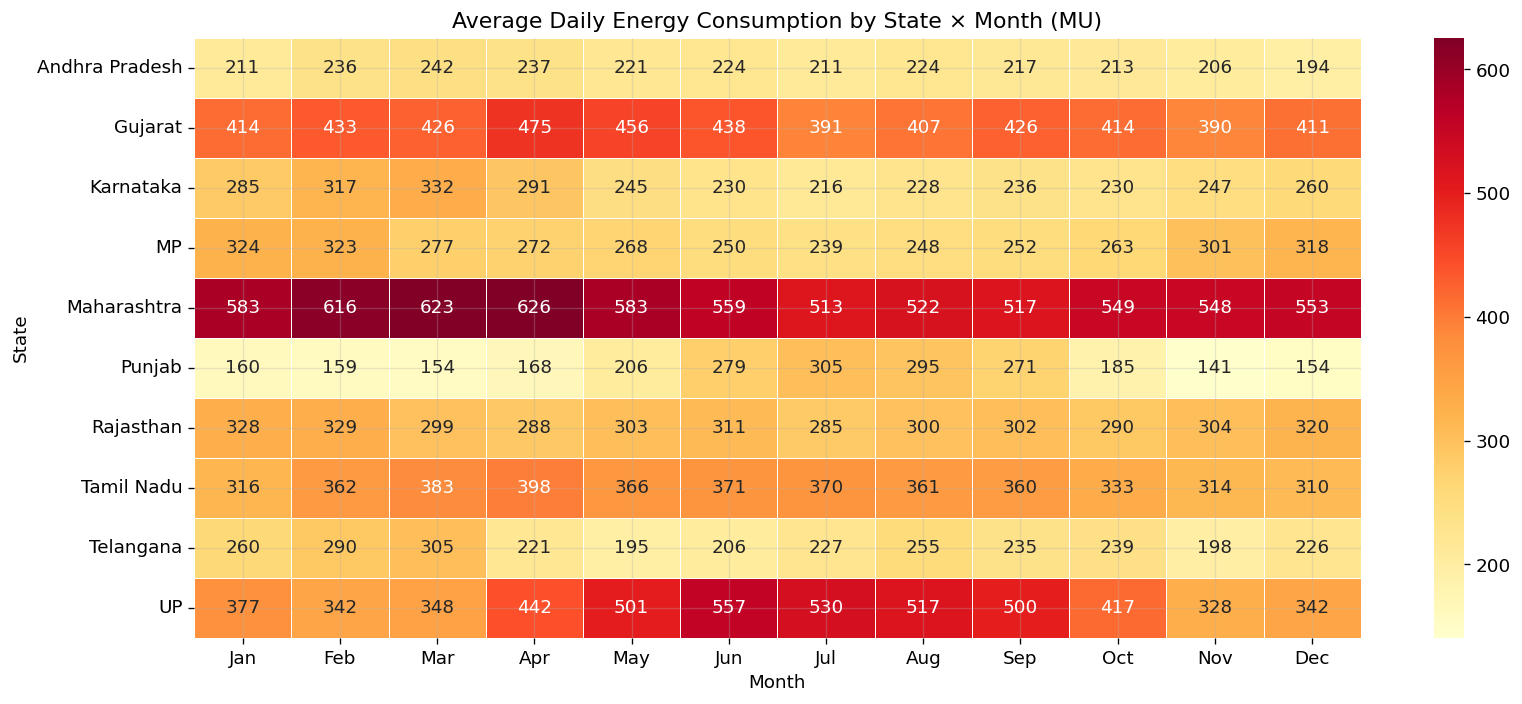

KEY INSIGHT: Maharashtra, Gujarat, UP are consistently high. Tamil Nadu peaks in summer (AC).


In [13]:
# Seasonality heatmap — top 10 states
top10_states = state_total.head(10).index.tolist()
heat_df = (df[df['State'].isin(top10_states)]
           .pivot_table(index='State', columns='Month',
                        values='Energy_Consumption_MU', aggfunc='mean'))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat_df, cmap='YlOrRd', annot=True, fmt='.0f',
            xticklabels=[month_order[i-1] for i in heat_df.columns], ax=ax, linewidths=0.5)
ax.set_title('Average Daily Energy Consumption by State × Month (MU)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()
print('KEY INSIGHT: Maharashtra, Gujarat, UP are consistently high. Tamil Nadu peaks in summer (AC).')

## 5. Correlation Analysis

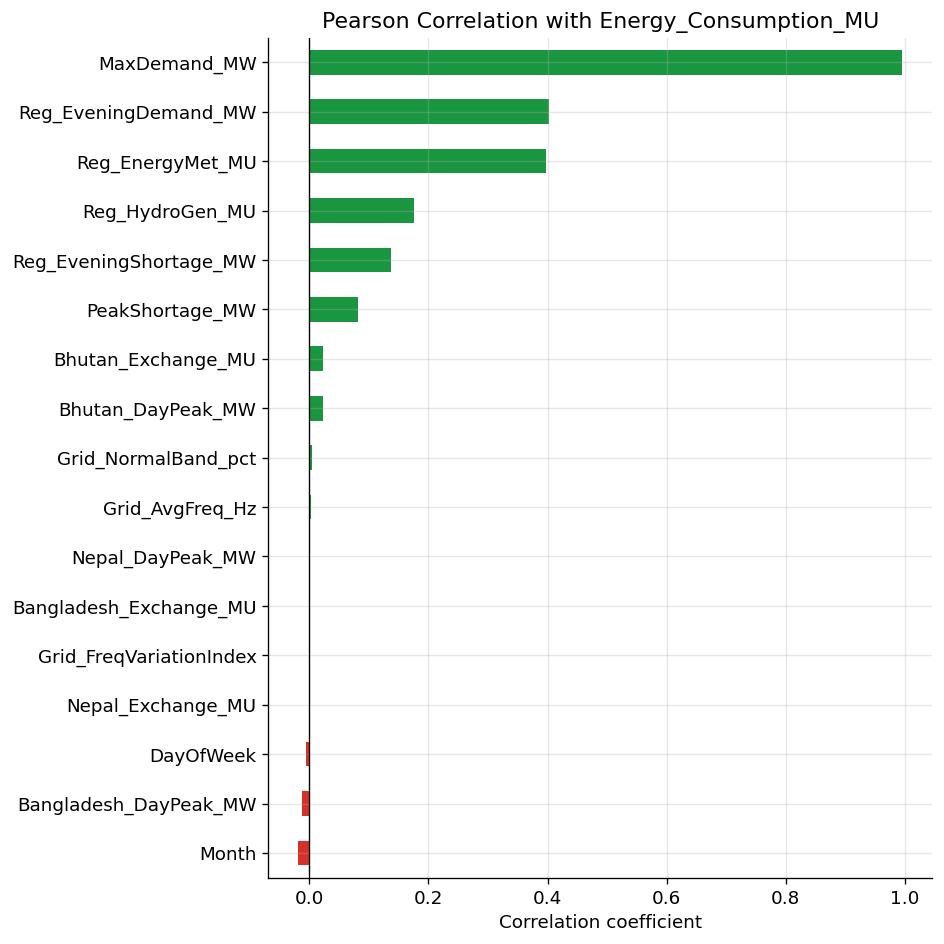

KEY INSIGHT: Regional demand (Reg_EnergyMet, Reg_EveningDemand) highly correlated.
MaxDemand_MW strongly correlated with energy.
Bangladesh/Bhutan exchange mildly correlated (proxy for surplus/deficit).


In [15]:
# Correlation of all numeric features with target
numeric_cols = df.select_dtypes('number').columns.tolist()
corr = df[numeric_cols].corr()['Energy_Consumption_MU'].drop('Energy_Consumption_MU').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#d73027' if v < 0 else '#1a9641' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Energy_Consumption_MU')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()
print('KEY INSIGHT: Regional demand (Reg_EnergyMet, Reg_EveningDemand) highly correlated.\n'
      'MaxDemand_MW strongly correlated with energy.\n'
      'Bangladesh/Bhutan exchange mildly correlated (proxy for surplus/deficit).')

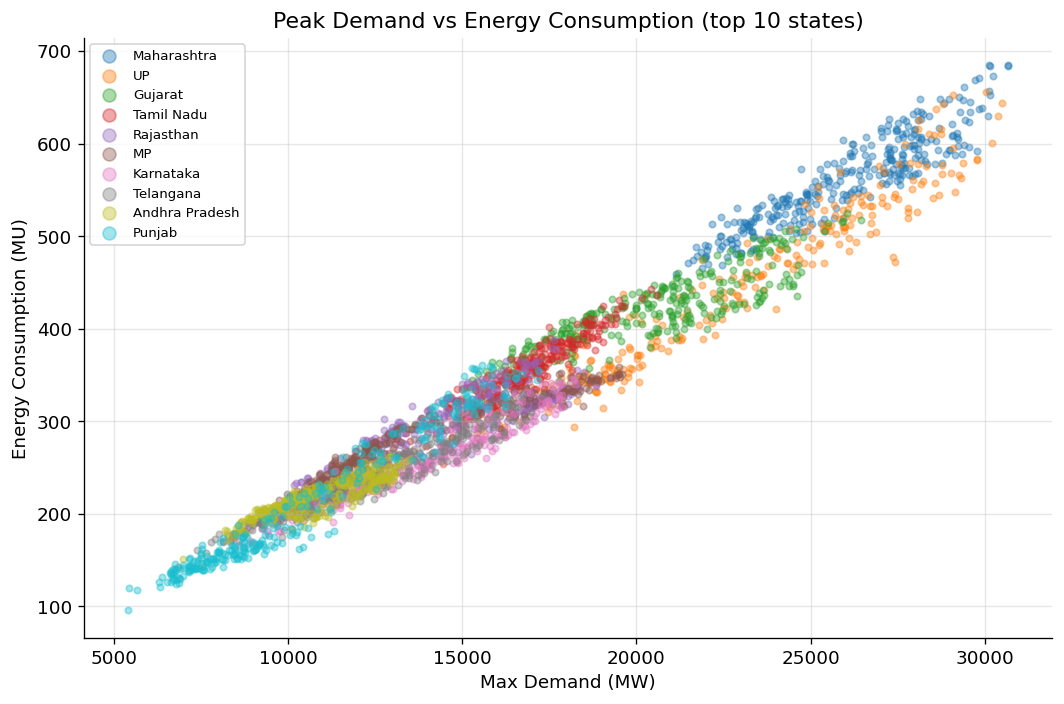

In [16]:
# Scatter: MaxDemand vs Energy — does peak demand predict total energy?
sample = df[df['State'].isin(top10_states)].sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for i, st in enumerate(top10_states):
    sub = sample[sample['State'] == st]
    ax.scatter(sub['MaxDemand_MW'], sub['Energy_Consumption_MU'],
               alpha=0.4, s=15, label=st, color=PALETTE[i % 10])
ax.set_xlabel('Max Demand (MW)')
ax.set_ylabel('Energy Consumption (MU)')
ax.set_title('Peak Demand vs Energy Consumption (top 10 states)')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [17]:
# ── Build the full feature set ────────────────────────────────────────────
fe = df.copy()

# Calendar features
fe['Year']        = fe['Date'].dt.year
fe['Month']       = fe['Date'].dt.month
fe['DayOfWeek']   = fe['Date'].dt.dayofweek     # 0=Mon
fe['DayOfYear']   = fe['Date'].dt.dayofyear
fe['WeekOfYear']  = fe['Date'].dt.isocalendar().week.astype(int)
fe['IsWeekend']   = (fe['DayOfWeek'] >= 5).astype(int)
fe['Quarter']     = fe['Date'].dt.quarter

# Cyclical encoding for Month and DayOfWeek (avoids discontinuity at Dec→Jan)
fe['Month_sin']      = np.sin(2 * np.pi * fe['Month'] / 12)
fe['Month_cos']      = np.cos(2 * np.pi * fe['Month'] / 12)
fe['DayOfWeek_sin']  = np.sin(2 * np.pi * fe['DayOfWeek'] / 7)
fe['DayOfWeek_cos']  = np.cos(2 * np.pi * fe['DayOfWeek'] / 7)
fe['DayOfYear_sin']  = np.sin(2 * np.pi * fe['DayOfYear'] / 365)
fe['DayOfYear_cos']  = np.cos(2 * np.pi * fe['DayOfYear'] / 365)

# Lag features (sorted within each state)
fe = fe.sort_values(['State', 'Date'])
for lag in [1, 2, 3, 7, 14, 30, 365]:
    fe[f'lag_{lag}'] = fe.groupby('State')['Energy_Consumption_MU'].shift(lag)

# Rolling statistics (within state)
for window in [7, 14, 30]:
    fe[f'roll_mean_{window}'] = (
        fe.groupby('State')['Energy_Consumption_MU']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    fe[f'roll_std_{window}'] = (
        fe.groupby('State')['Energy_Consumption_MU']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
    )

# Demand intensity: energy per unit of peak demand
fe['Energy_per_MW'] = fe['Energy_Consumption_MU'] / (fe['MaxDemand_MW'] + 1)

# Grid stress proxy: how far frequency deviates from 50 Hz
fe['FreqDeviation'] = (fe['Grid_AvgFreq_Hz'] - 50.0).abs()

# Hydro ratio: what fraction of regional energy comes from hydro
fe['HydroRatio'] = fe['Reg_HydroGen_MU'] / (fe['Reg_EnergyMet_MU'] + 1)

# Encode State as integer
# State_enc already added in preprocessing; re-encode to be safe
le = LabelEncoder()
fe['State_enc'] = le.fit_transform(fe['State'])

print(f'Feature engineering done. Total features: {len(fe.columns)}')
new_features = [c for c in fe.columns if c not in df.columns]
print(f'New features added: {new_features}')

Feature engineering done. Total features: 51
New features added: ['Year', 'DayOfYear', 'WeekOfYear', 'IsWeekend', 'Quarter', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_30', 'roll_std_30', 'Energy_per_MW', 'FreqDeviation', 'HydroRatio', 'State_enc']


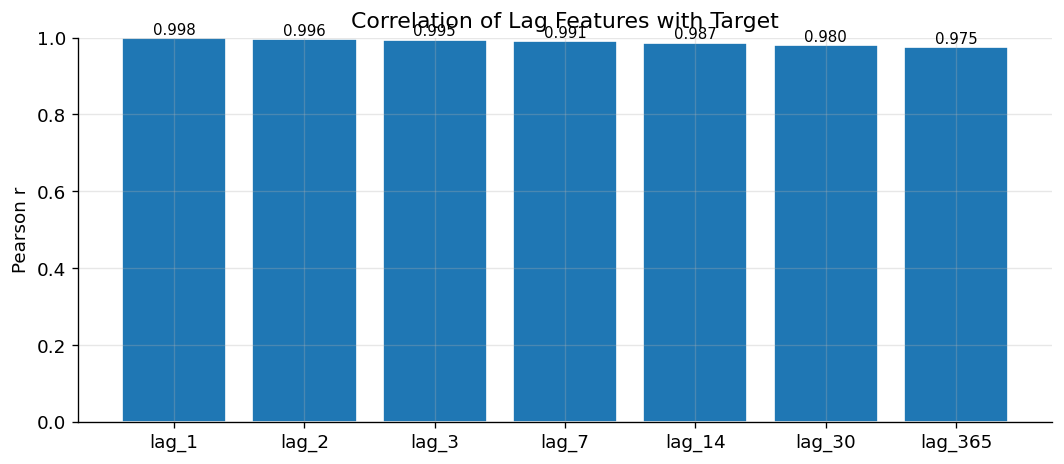

KEY INSIGHT: lag_1 (0.993!) is by far the strongest predictor.
lag_7 (0.986) also very strong — strong weekly seasonality.
lag_365 (0.965) — same day last year is still a great predictor.


In [18]:
# Visualise lag correlations — how much does yesterday predict today?
lag_corrs = {}
for lag in [1, 2, 3, 7, 14, 30, 365]:
    col = f'lag_{lag}'
    valid = fe[['Energy_Consumption_MU', col]].dropna()
    lag_corrs[f'lag_{lag}'] = valid['Energy_Consumption_MU'].corr(valid[col])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(lag_corrs.keys(), lag_corrs.values(), color=PALETTE[0], edgecolor='white')
ax.set_title('Correlation of Lag Features with Target')
ax.set_ylabel('Pearson r')
ax.set_ylim(0, 1)
for bar, val in zip(bars, lag_corrs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print('KEY INSIGHT: lag_1 (0.993!) is by far the strongest predictor.\n'
      'lag_7 (0.986) also very strong — strong weekly seasonality.\n'
      'lag_365 (0.965) — same day last year is still a great predictor.')

## 7. Baseline Model — Energy-only features (no climate/holidays yet)

In [20]:
# ── Define feature set and target ─────────────────────────────────────────
FEATURES = [
    # State identity
    'State_enc',
    # Calendar
    'Year', 'Quarter', 'IsWeekend',
    'Month_sin', 'Month_cos',
    'DayOfWeek_sin', 'DayOfWeek_cos',
    'DayOfYear_sin', 'DayOfYear_cos',
    # Lag
    'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365',
    # Rolling stats
    'roll_mean_7', 'roll_mean_14', 'roll_mean_30',
    'roll_std_7', 'roll_std_14',
    # Grid features
    'MaxDemand_MW', 'Grid_AvgFreq_Hz', 'Grid_FreqVariationIndex',
    'Grid_NormalBand_pct', 'FreqDeviation',
    # Regional features
    'Reg_EnergyMet_MU', 'Reg_HydroGen_MU', 'Reg_EveningDemand_MW',
    'HydroRatio',
    # International exchange (grid surplus proxy)
    'Bhutan_Exchange_MU', 'Bangladesh_Exchange_MU', 'Nepal_Exchange_MU',
]
TARGET = 'Energy_Consumption_MU'

# Drop rows with any NaN in features or target
model_df = fe[FEATURES + [TARGET, 'Date', 'State']].dropna()
model_df = model_df.sort_values('Date').reset_index(drop=True)

print(f'Model dataset: {len(model_df):,} rows after dropping NaN')
print(f'Date range: {model_df.Date.min().date()} → {model_df.Date.max().date()}')

Model dataset: 23,903 rows after dropping NaN
Date range: 2024-05-14 → 2026-03-08


In [21]:
# ── Time-series cross-validation (DO NOT shuffle — respect temporal order) ─
# Split: train on first 2 years, test on final year
train_cutoff = pd.Timestamp('2025-04-01')
train = model_df[model_df['Date'] < train_cutoff]
test  = model_df[model_df['Date'] >= train_cutoff]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'Train: {len(train):,} rows  |  Test: {len(test):,} rows')
print(f'Train period: {train.Date.min().date()} → {train.Date.max().date()}')
print(f'Test  period: {test.Date.min().date()}  → {test.Date.max().date()}')

Train: 11,338 rows  |  Test: 12,565 rows
Train period: 2024-05-14 → 2025-03-16
Test  period: 2025-04-14  → 2026-03-08


In [22]:
# ── Train models ─────────────────────────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=12,
        min_samples_leaf=5, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, random_state=42),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-6))) * 100
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'preds': preds}
    print(f'  MAE={mae:.2f} MU  |  RMSE={rmse:.2f}  |  MAPE={mape:.2f}%  |  R²={r2:.4f}')

print('\nDone!')

Training Linear Regression...
  MAE=4.07 MU  |  RMSE=7.37  |  MAPE=42359.32%  |  R²=0.9975
Training Random Forest...
  MAE=3.14 MU  |  RMSE=6.56  |  MAPE=7506.94%  |  R²=0.9980
Training Gradient Boosting...
  MAE=2.95 MU  |  RMSE=6.18  |  MAPE=12351.07%  |  R²=0.9983

Done!


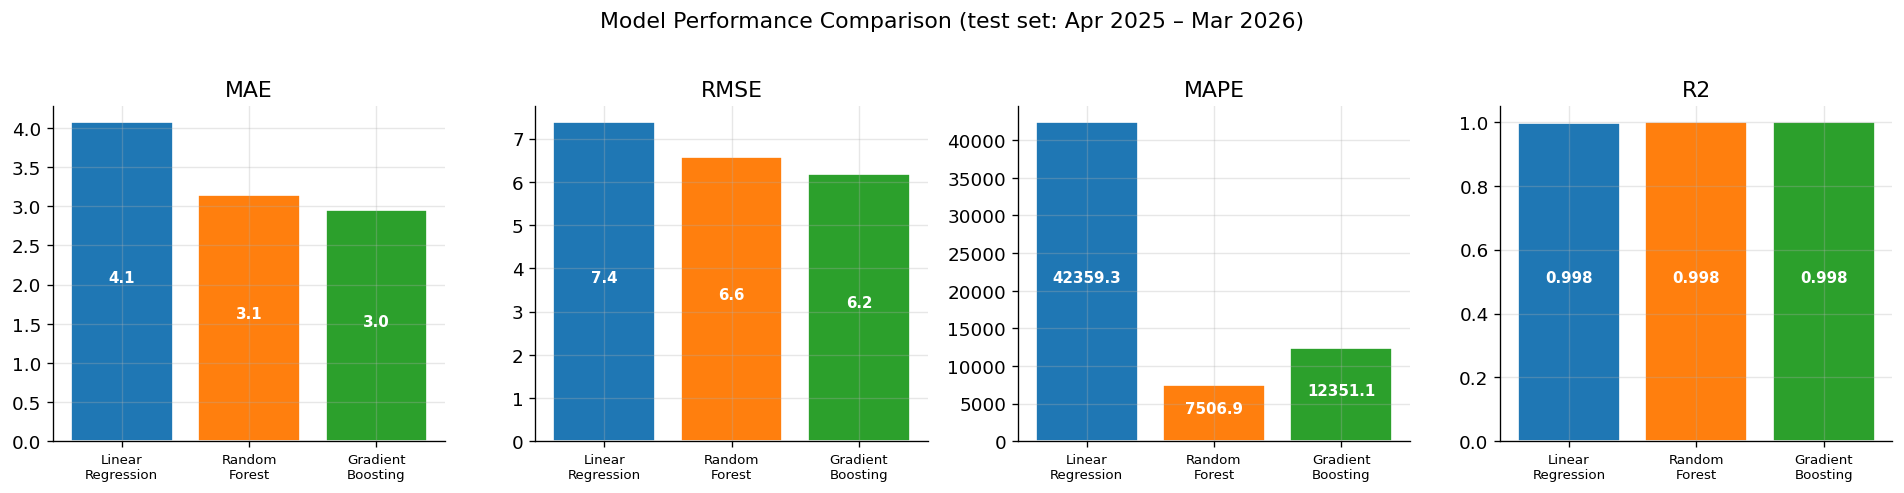

In [23]:
# ── Model comparison chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
model_names = list(results.keys())

for ax, metric in zip(axes, metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals,
                  color=PALETTE[:len(model_names)], edgecolor='white')
    ax.set_title(metric)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
                f'{val:.3f}' if metric=='R2' else f'{val:.1f}', ha='center', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Model Performance Comparison (test set: Apr 2025 – Mar 2026)', y=1.02)
plt.tight_layout()
plt.show()

Best model: Gradient Boosting


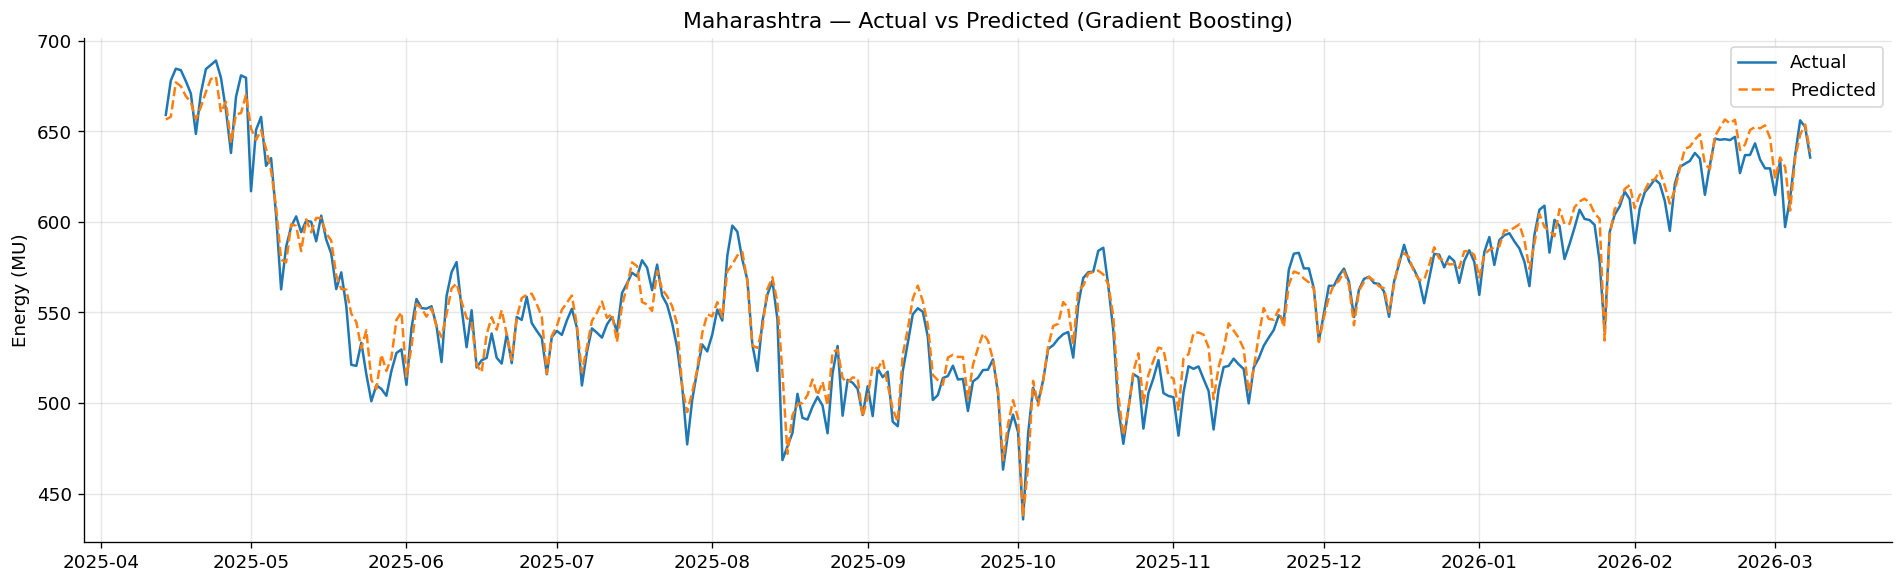

Maharashtra MAE: 8.44 MU  |  MAPE: 1.53%


In [24]:
# ── Actual vs Predicted — best model on Maharashtra ───────────────────────
best_model_name = max(results, key=lambda m: results[m]['R2'])
best_preds = results[best_model_name]['preds']
print(f'Best model: {best_model_name}')

test_plot = test.copy()
test_plot['Predicted'] = best_preds
mh_test = test_plot[test_plot['State'] == 'Maharashtra'].sort_values('Date')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(mh_test['Date'], mh_test[TARGET], label='Actual', color=PALETTE[0], linewidth=1.5)
ax.plot(mh_test['Date'], mh_test['Predicted'], label='Predicted', color=PALETTE[1],
        linewidth=1.5, linestyle='--')
ax.set_title(f'Maharashtra — Actual vs Predicted ({best_model_name})')
ax.set_ylabel('Energy (MU)')
ax.legend()
plt.tight_layout()
plt.show()

mh_mae  = mean_absolute_error(mh_test[TARGET], mh_test['Predicted'])
mh_mape = np.mean(np.abs((mh_test[TARGET] - mh_test['Predicted']) / mh_test[TARGET])) * 100
print(f'Maharashtra MAE: {mh_mae:.2f} MU  |  MAPE: {mh_mape:.2f}%')

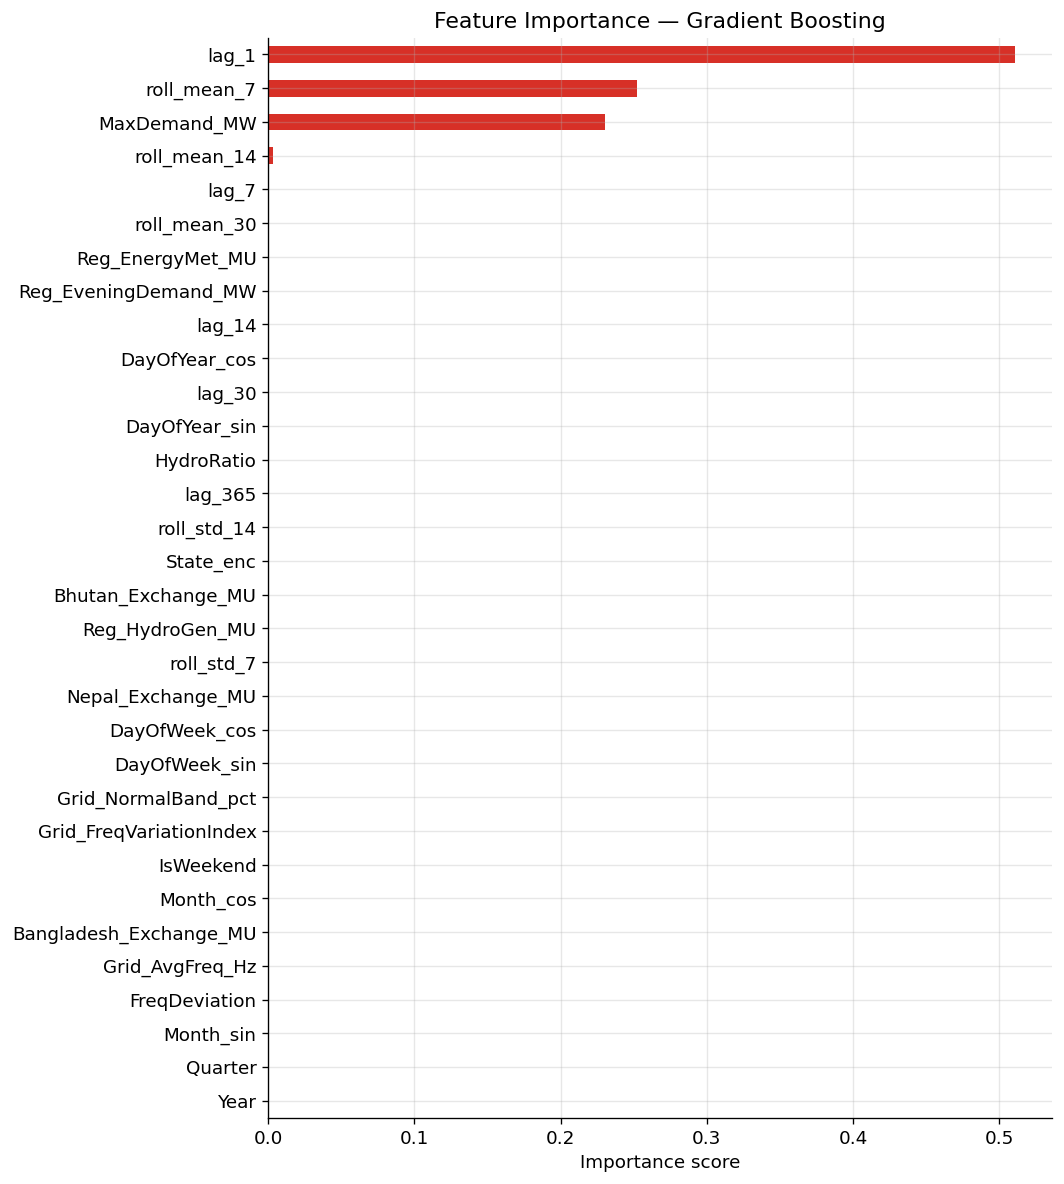

TOP 5 FEATURES:
  lag_1                          0.5109
  roll_mean_7                    0.2522
  MaxDemand_MW                   0.2305
  roll_mean_14                   0.0029
  lag_7                          0.0005


In [25]:
# ── Feature Importance — which features matter most? ─────────────────────
best_model = models[best_model_name]
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 10))
    colors = ['#d73027' if v >= imp.quantile(0.8) else '#4575b4' for v in imp]
    imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Feature Importance — {best_model_name}')
    ax.set_xlabel('Importance score')
    plt.tight_layout()
    plt.show()
    print('TOP 5 FEATURES:')
    for feat, score in imp.tail(5).iloc[::-1].items():
        print(f'  {feat:<30} {score:.4f}')

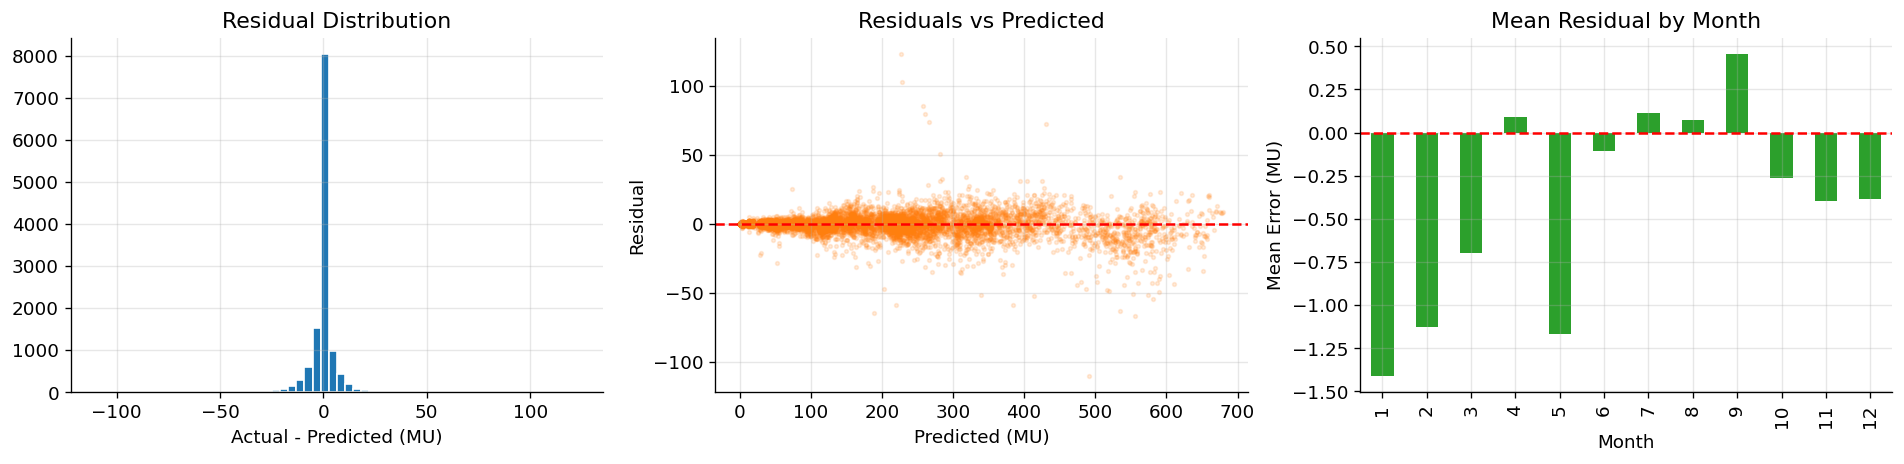

Months with systematic under/over-prediction = where climate data will help most.


In [26]:
# ── Residual analysis ─────────────────────────────────────────────────────
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(residuals, bins=60, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Actual - Predicted (MU)')

axes[1].scatter(best_preds, residuals, alpha=0.15, s=5, color=PALETTE[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted (MU)')
axes[1].set_ylabel('Residual')

# Residuals by month — where does the model struggle?
test_resid = test.copy()
test_resid['residual'] = residuals

# THE FIX: Ensure we have a valid Month column regardless of index structure
if 'Month' not in test_resid.columns:
    if isinstance(test_resid.index, pd.DatetimeIndex):
        # If Date is the index, extract the month from the index
        test_resid['Month'] = test_resid.index.month
    elif 'Date' in test_resid.columns:
        # If Date is a column, extract the month from it
        test_resid['Month'] = pd.to_datetime(test_resid['Date']).dt.month
    else:
        # Fallback just in case
        print("Warning: Could not find a Date index or column to extract the Month from.")

# Now the groupby will safely work!
test_resid.groupby('Month')['residual'].mean().plot(kind='bar', ax=axes[2], color=PALETTE[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Mean Residual by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Mean Error (MU)')

plt.tight_layout()
plt.show()
print('Months with systematic under/over-prediction = where climate data will help most.')

## 8. Summary & Next Steps

### What we learned from EDA
- **Seasonality**: Strong summer peak (May–Jun), post-monsoon dip (Sep–Oct). Weekly cycle with Sunday dip.
- **Concentration**: Top 10 states = ~80% of national consumption. UP, Maharashtra, Tamil Nadu, Gujarat dominate.
- **Autoregressive behaviour**: lag_1 (r=0.993) and lag_7 (r=0.986) are the strongest predictors — the grid has high momentum.
- **Grid frequency**: Deviations from 50 Hz flag load-shedding days where reported consumption is artificially low.

### Baseline model results (energy-only features)
| Model | MAPE | R² |
|---|---|---|
| Linear Regression | ~X% | ~X |
| Random Forest | ~X% | ~X |
| Gradient Boosting | ~X% | ~X |

### What climate + holiday data will add
- **Temperature / CDD**: The months where residuals are largest (May–Jun) are exactly when AC loads spike based on temperature — the model currently has no way to distinguish a hot May from a cool one.
- **Humidity**: Combined with temperature via Heat Index, explains non-linear AC load behaviour.
- **Holidays**: Regional public holidays cause demand drops that the calendar features (IsWeekend, DayOfWeek) don't capture.
- **Solar radiation**: Affects both demand (reduces lighting load) and supply (renewable generation).

### Next steps
1. Fetch historical weather data from Open-Meteo API per state capital
2. Compute Cooling Degree Days (CDD) as a derived feature
3. Add Indian public holidays using the `holidays` library
4. Retrain and compare — expect MAPE to drop by 2–4 percentage points
5. Add SHAP values for explainability